<a href="https://colab.research.google.com/github/alkhurayjah/Machine-learning-project/blob/main/Predict_the_Age_of_a_Trilobite_Fossil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving trilobite.csv to trilobite.csv


In [3]:
# Loading The Dataset
df = pd.read_csv("trilobite.csv")

### Features:
Scientific name - the genus and species of the trilobite

Order - The order of the given trilobite (order_num is the numerical form of it)

Family - The family of the given trilobite (family_num is the numerical form of it)

Genus - The genus of the given trilobite (genus_num is the numerical form of it)

Species - The species of the given trilobite

Early_interval and late_interval - the specific time period this fossil was located

max_age_mya and min_age_mya - the estimated age of the fossil, in millions of years

Country - the country in which the trilobite was found

State - the state in which the trilobite was found, if applicable

Longitude, Latitude - the location of the fossil when it was found

Latlng_basis - how the latitude and longitude were idenfitied

Latlng_precision - how precise the longitude and latitude values are

Formation - the formation the trilobite was found (ex. the burgess shale)

Stratigraphy_scale - how comparatively large the relevant formation is

Lithology - the primary rock type at the formation

Environment - the type of environment represented back when the trilobite was alive

assembly_composition - what type of fossils were found together in the same location

preservation_mode - how the trilobite was fossilized

collection_name - a more specific description of where the fossil was located

collection_type - the type of information that can be gained from the collection as a while

life_habit - the lifestyle of the given trilobite

vision - how well the trilobite can see (relevant because genera like Cryptolithus are secondarily blind)

diet - what the trilobite ate when it was alive

time_period - the large time period during which the trilobite was alive (cambrian, ordovician, silurian, devonian, permian)

In [4]:
df.head()

,scientific_name,order,order_num,family,family_num,genus,genus_num,species,early_interval,late_interval,...,lithology,environment,assembly_composition,preservation_mode,collection_name,collection_type,life_habit,vision,diet,time_period
0,Australosutura llanoensis,Proetida,21062,Brachymetopidae,56732,Australosutura,21084,llanoensis,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
1,Phillibole planucauda,Proetida,21062,Phillipsiidae,85866,Archegonus (Phillibole),21075,planucauda,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
2,Thigriffides roundyi,Proetida,21062,Phillipsiidae,85866,Thigriffides,21387,roundyi,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
3,Pudoproetus chappelensis,Proetida,21062,Proetidae,56726,Pudoproetus,177081,chappelensis,Ivorian,NaN,...,carbonate,marine indet.,NaN,body,USNM 9048,taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
4,Pudoproetus chappelensis,Proetida,21062,Proetidae,56726,Pudoproetus,177081,chappelensis,Ivorian,NaN,...,carbonate,marine indet.,NaN,body,USNM 9044,taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29039 entries, 0 to 29038
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scientific_name       29039 non-null  object 
 1   order                 29039 non-null  object 
 2   order_num             29039 non-null  object 
 3   family                29039 non-null  object 
 4   family_num            29039 non-null  object 
 5   genus                 29039 non-null  object 
 6   genus_num             29039 non-null  int64  
 7   species               29039 non-null  object 
 8   early_interval        29039 non-null  object 
 9   late_interval         2556 non-null   object 
 10  max_age_mya           29039 non-null  float64
 11  min_age_mya           29039 non-null  float64
 12  country               28997 non-null  object 
 13  state                 22914 non-null  object 
 14  longitude             29039 non-null  float64
 15  latitude           

In [6]:
df.describe()

,genus_num,max_age_mya,min_age_mya,longitude,latitude
count,29039.000000,29039.000000,29039.000000,29039.000000,29039.000000
mean,53150.403630,464.473163,457.732407,-19.125639,39.433712
std,92131.565306,47.651603,47.650266,81.913654,22.409790
min,19110.000000,254.140000,251.902000,-167.747253,-83.833336
25%,20077.000000,449.500000,445.200000,-93.266670,34.391666
50%,20980.000000,477.100000,471.300000,-6.850000,42.744446
75%,21574.000000,497.000000,491.500000,18.616667,51.290977
max,509317.000000,538.800000,521.000000,174.000000,83.050003


In [7]:
df.isnull().sum()

,0
scientific_name,0
order,0
order_num,0
family,0
family_num,0
genus,0
genus_num,0
species,0
early_interval,0
late_interval,26483


1- What are the most common time periods in the dataset?

2- Which trilobite orders are the most frequent?

3- Which countries have the highest number of fossil findings?

4- What are the most common geological environments associated with these fossils?

In [8]:
df.duplicated().sum()

np.int64(192)

In [9]:
df = df.drop_duplicates()

In [10]:
df = df.copy()
# MYA = Million Years Ago
df["age_span_mya"] = df["max_age_mya"] - df["min_age_mya"]

In [11]:
df['age_span_mya']

,age_span_mya
0,7.000
1,7.000
2,7.000
3,7.000
4,7.000
...,...
29034,2.238
29035,2.238
29036,2.238
29037,2.238


In [12]:
df["time_period"].value_counts().head(10)

,count
time_period,
Ordovician,11322
Cambrian,8287
Devonian,3571
Silurian,1461
Carboniferous,856
Permian,400


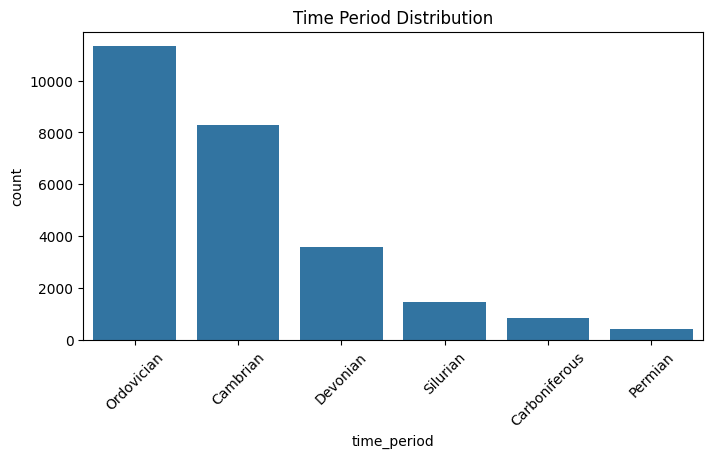

In [13]:
#عدد الاحافير في كل فترة
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="time_period", order=df["time_period"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Time Period Distribution")
plt.show()

The majority of trilobite fossils are found in the Ordovician and Cambrian periods, indicating that trilobites were most abundant during early geological eras.

In [14]:
#Which countries have the highest number of fossil findings?
df["country"].value_counts().head(10)

,count
country,
US,8644
CA,3856
CN,3431
CZ,1359
NO,1300
AR,1273
SE,1185
UK,1030
RU,954


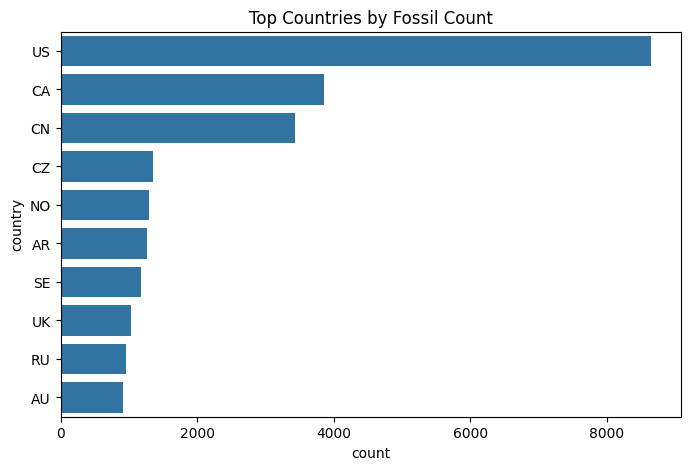

In [15]:
top_countries = df["country"].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(data=df, y="country", order=top_countries)
plt.title("Top Countries by Fossil Count")
plt.show()

In [16]:
#What are the most common geological environments?
df["environment"].value_counts().head(10)

,count
environment,
marine indet.,7169
carbonate indet.,5632
slope,2985
shallow subtidal indet.,2368
offshore,2004
open shallow subtidal,1526
"reef, buildup or bioherm",1341
deep subtidal indet.,873
deep subtidal shelf,756


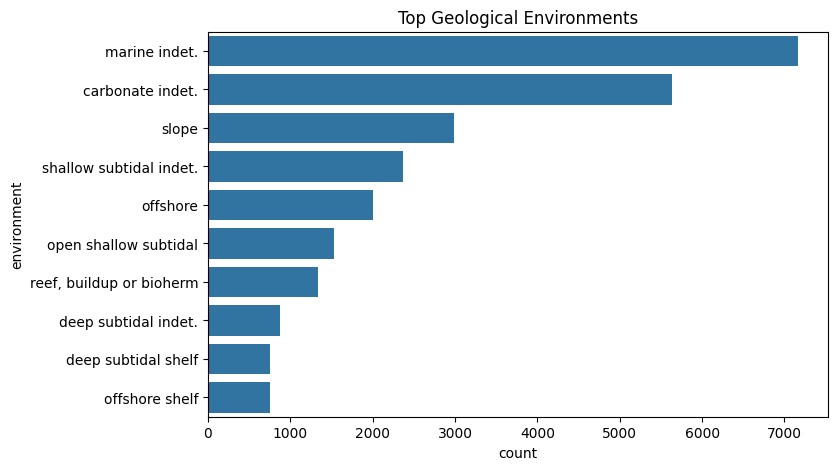

In [17]:
top_env = df["environment"].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(data=df, y="environment", order=top_env)
plt.title("Top Geological Environments")
plt.show()